# StarDist, layer by layer

A visual walk through **`mini_stardist.py`** — the single-file, NumPy-only
StarDist (`2D_versatile_fluo`) nucleus segmenter in this repo, and a sibling to
[`mini_cellpose_walkthrough.ipynb`](mini_cellpose_walkthrough.ipynb). Each stage
below runs one piece of the pipeline and plots what comes out.

**StarDist in three ideas**

1. A U-Net predicts, at every pixel of a coarse output grid, an **object
   probability** and **32 radial distances** — how far it is to the object
   boundary along 32 rays fanning out at equal angles. Probability + 32 distances
   = one candidate **star-convex polygon** centered on that pixel.
2. Every pixel above threshold proposes a polygon, so each nucleus is proposed
   hundreds of times by its neighbours. **Non-maximum suppression** keeps the
   highest-probability polygon and discards every other polygon overlapping it
   too much — collapsing each cloud of proposals to one.
3. Rasterize the survivors into a label image.

Where Cellpose reads a *flow field* and integrates *dynamics* to find centers,
StarDist reads the shape **directly** off 32 distance channels — no flow, no
iteration. And this net has **no BatchNorm**. Everything is imported from
`mini_stardist`, so the plots use the exact same code path as the command line.

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mini_stardist as ms

plt.rcParams["figure.dpi"] = 90

# pretrained 2D_versatile_fluo weights (exported once by export_stardist.py) + a sample image
W, meta = ms.load_weights("stardist_fluo_weights.bin", "stardist_fluo_manifest.json")
gray = ms.load_gray("images/cellpose_img_075.png")
H, Wd = gray.shape
PROB_THRESH, NMS_THRESH, GRID = 0.4791, 0.3, (2, 2)
print(f"weights: {len(meta['tensors'])} tensors   image: {Wd}x{H}")

# ---- little plotting helpers, reused throughout ----
def show_channels(feat, n=8, title=""):
    "Show the first n channels of a [C,H,W] feature map."
    C = feat.shape[0]; n = min(C, n)
    fig, axs = plt.subplots(1, n, figsize=(1.9*n, 2.3))
    for i in range(n):
        axs[i].imshow(feat[i], cmap="magma"); axs[i].set_title(f"ch{i}", fontsize=8); axs[i].axis("off")
    fig.suptitle(f"{title}   [{C} channels, {feat.shape[1]}x{feat.shape[2]}]", y=1.02)
    plt.show()

def draw_polys(ax, coords, **kw):
    "Draw each star-convex polygon; coords is (n,2,32) = (poly, [y,x], ray)."
    for c in coords:
        ys = np.append(c[0], c[0][0]); xs = np.append(c[1], c[1][0])   # close the loop
        ax.plot(xs, ys, **kw)

def label_overlay(gray, labels):
    "Overlay integer masks on the image with a random color per label."
    g = (gray - gray.min()) / (np.ptp(gray) + 1e-9)
    rgb = np.stack([g]*3, -1) * 0.5
    lut = np.random.default_rng(0).random((int(labels.max())+1, 3)); lut[0] = 0
    m = labels > 0
    rgb[m] = 0.35*rgb[m] + 0.65*lut[labels[m]]
    return rgb

weights: 38 tensors   image: 240x300


## 1. Preprocessing

StarDist normalizes with a percentile stretch (csbdeep's default, **1–99.8**),
then we reflect-pad so both dimensions are multiples of 16 (the net pools 4×).
The input is a single grayscale channel.

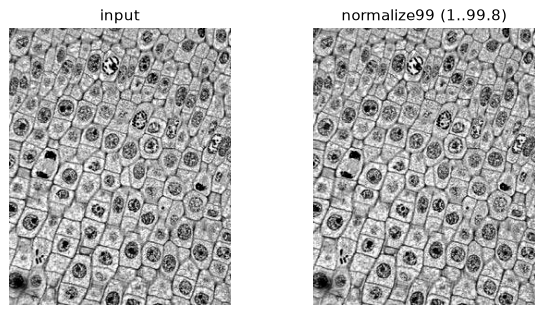

input shape: (300, 240)  padded: (304, 240)


In [10]:
norm = ms.normalize99(gray)                     # percentile 1..99.8
padded, _ = ms.pad_to(norm, 16)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(gray, cmap="gray"); ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(norm, cmap="gray"); ax[1].set_title("normalize99 (1..99.8)"); ax[1].axis("off")
plt.show()
print("input shape:", norm.shape, " padded:", padded.shape)

## 2. Encoder (the contracting path)

An initial `conv → conv → maxpool` block downsamples to the **(2,2) output
grid**; then a depth-3 U-Net contracts further (32 → 64 → 128 filters), halving
resolution and doubling receptive field at each level. We run the layers by hand
so we can look at the feature maps.

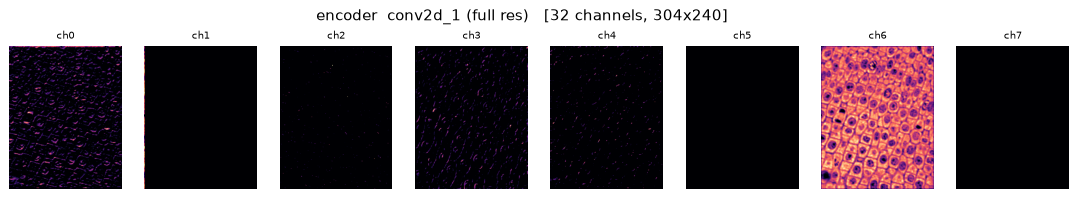

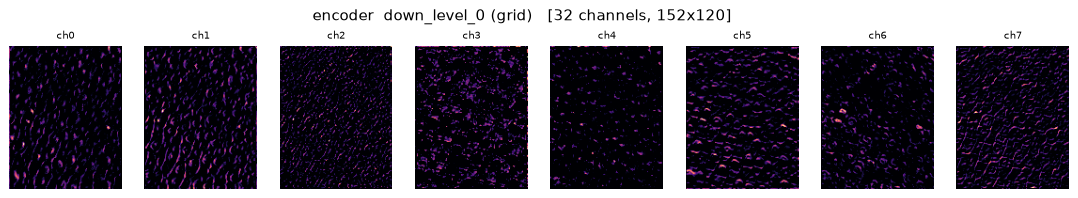

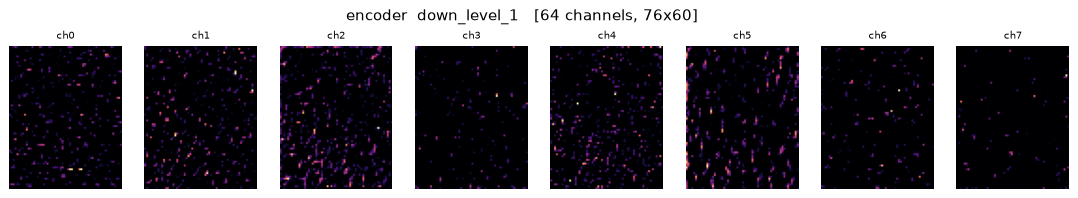

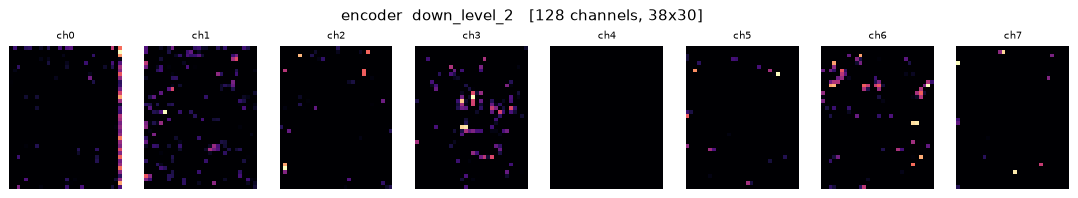

In [11]:
def cr(name, y):                                # conv + ReLU (no BatchNorm here)
    return ms.relu(ms.conv2d(y, W[name + ".w"], W[name + ".b"]))

x = padded[None]                                # [1, Hp, Wp]
c1 = cr("conv2d_1", cr("conv2d", x))            # full-res block (feeds the grid pool)
d0 = cr("down_level_0_no_1", cr("down_level_0_no_0", ms.maxpool2(c1)))   # grid res (/2)
d1 = cr("down_level_1_no_1", cr("down_level_1_no_0", ms.maxpool2(d0)))   # /4
d2 = cr("down_level_2_no_1", cr("down_level_2_no_0", ms.maxpool2(d1)))   # /8
for name, feat in [("conv2d_1 (full res)", c1), ("down_level_0 (grid)", d0),
                   ("down_level_1", d1), ("down_level_2", d2)]:
    show_channels(feat, 8, "encoder  " + name)

## 3. Bottleneck + decoder (the expanding path)

The bottleneck sees the whole image at the coarsest scale. The decoder then
upsamples and **concatenates the matching encoder skip** at each level (upsampled
features first, then the skip — the order the conv weights expect), recovering
spatial detail up to the (2,2) grid.

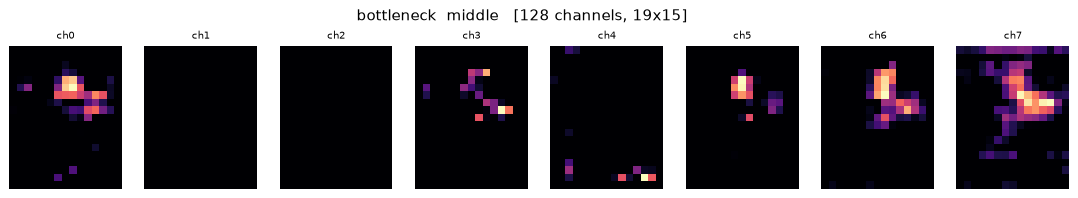

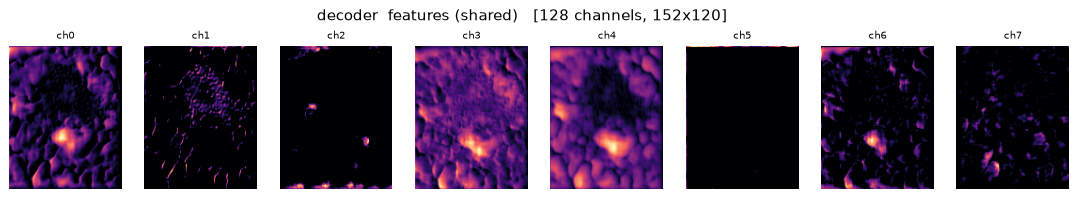

In [12]:
m = cr("middle_2", cr("middle_0", ms.maxpool2(d2)))         # bottleneck (/16)
u = np.concatenate([ms.upsample2(m), d2], axis=0)           # skip: up first, then encoder
u = cr("up_level_2_no_2", cr("up_level_2_no_0", u))
u = np.concatenate([ms.upsample2(u), d1], axis=0)
u = cr("up_level_1_no_2", cr("up_level_1_no_0", u))
u = np.concatenate([ms.upsample2(u), d0], axis=0)
u = cr("up_level_0_no_2", cr("up_level_0_no_0", u))
feats = cr("features", u)                                    # shared feature map for both heads
show_channels(m, 8, "bottleneck  middle")
show_channels(feats, 8, "decoder  features (shared)")

## 4. The two heads — probability and distances

From the shared `features` map, two 1×1 convs branch off: **`prob`** (sigmoid →
objectness at every grid pixel) and **`dist`** (32 linear channels → the radial
distance to the boundary along each of the 32 rays). Below: the probability map,
and four of the 32 distance channels (each is "how far to the edge in *this*
direction").

grid 120x152   prob[max]=0.752   dist range [-4.1, 83.8] px


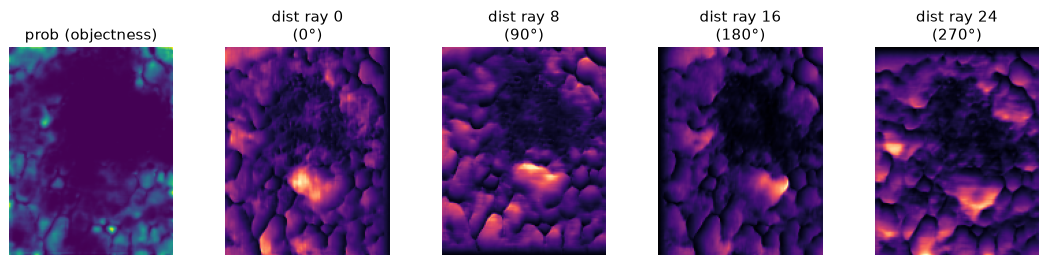

In [13]:
prob, dist = ms.unet_forward(W, padded[None])   # prob:[gh,gw]  dist:[gh,gw,32]
gh, gw = prob.shape
print(f"grid {gw}x{gh}   prob[max]={prob.max():.3f}   dist range [{dist.min():.1f}, {dist.max():.1f}] px")

fig, axs = plt.subplots(1, 5, figsize=(15, 3))
axs[0].imshow(prob, cmap="viridis"); axs[0].set_title("prob (objectness)"); axs[0].axis("off")
for j, k in enumerate([0, 8, 16, 24]):          # rays at 0, 90, 180, 270 degrees
    axs[j+1].imshow(dist[..., k], cmap="magma")
    axs[j+1].set_title(f"dist ray {k}\n({int(360*k/32)}°)"); axs[j+1].axis("off")
plt.show()

## 5. From distances to polygons

For a grid pixel at center *(y, x)*, ray *k* points at angle
$\phi_k = 2\pi k/32$ and its polygon vertex sits `dist[k]` pixels away:
$y + d\sin\phi,\; x + d\cos\phi$. Connect the 32 vertices and you have that
pixel's proposed nucleus outline. Here are the polygons for a few high-confidence
pixels, drawn over the image.

23 candidate polygons above prob_thresh=0.4791


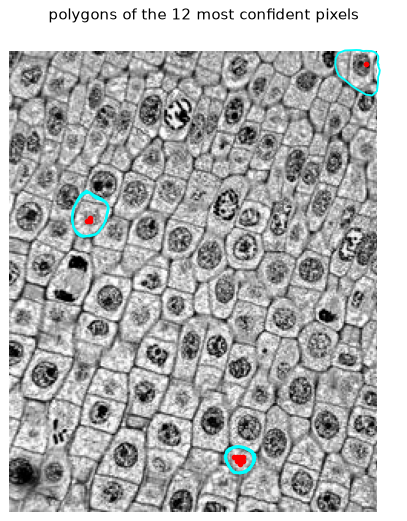

In [14]:
# candidate points: prob above threshold, minus a 2-px grid border
mask = prob > PROB_THRESH
mask[:2] = mask[-2:] = mask[:, :2] = mask[:, -2:] = False
gy, gx = np.nonzero(mask)
scores = prob[gy, gx]
dists = dist[gy, gx]                              # (n, 32)
points = np.stack([gy*GRID[0], gx*GRID[1]], 1).astype(float)   # -> full-res coords
print(f"{gy.size} candidate polygons above prob_thresh={PROB_THRESH}")

# draw the polygons of the 12 highest-probability candidates
top = np.argsort(scores)[::-1][:12]
coords = ms.dist_to_coord(dists[top], points[top])
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(gray, cmap="gray")
draw_polys(ax, coords, color="cyan", lw=1.5)
ax.scatter(points[top, 1], points[top, 0], c="red", s=12)
ax.set_title("polygons of the 12 most confident pixels"); ax.axis("off")
plt.show()

## 6. Non-maximum suppression — the heart of StarDist

Because hundreds of neighbouring pixels each propose a polygon, the raw
candidates are a redundant thicket (**left**). NMS walks them from highest
probability down and drops any polygon whose overlap with an already-kept one
exceeds `nms_thresh` — using StarDist's rule, overlap = $A_\cap / \min(A_1,A_2)$.
What survives is one clean polygon per nucleus (**right**). We zoom into a crop
so the collapse is visible.

23 candidates -> 3 kept after NMS


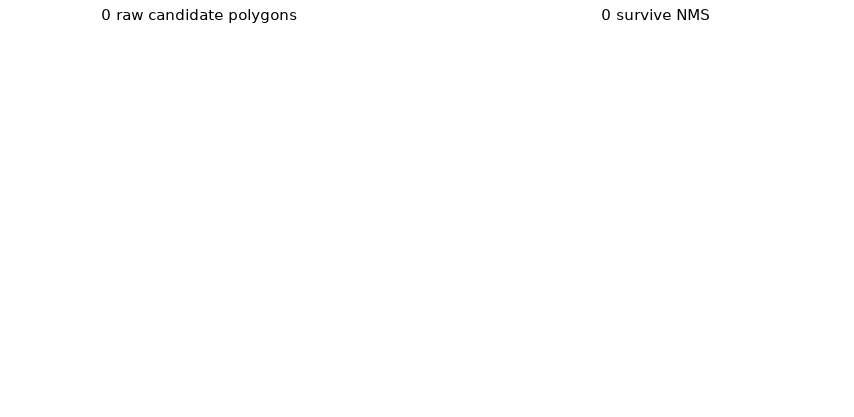

In [15]:
kept = ms.nms_polygons(points, dists, scores, padded.shape[0], padded.shape[1], NMS_THRESH)
print(f"{gy.size} candidates -> {kept.size} kept after NMS")

# a crop busy enough to show the thicket collapsing
cy, cx, sz = 300, 500, 90
def in_crop(pts):
    return (np.abs(pts[:, 0]-cy) < sz) & (np.abs(pts[:, 1]-cx) < sz)
cand_here = np.nonzero(in_crop(points))[0]
kept_here = kept[in_crop(points[kept])]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for a in ax:
    a.imshow(gray, cmap="gray"); a.set_xlim(cx-sz, cx+sz); a.set_ylim(cy+sz, cy-sz); a.axis("off")
draw_polys(ax[0], ms.dist_to_coord(dists[cand_here], points[cand_here]), color="cyan", lw=0.5, alpha=0.4)
ax[0].set_title(f"{cand_here.size} raw candidate polygons")
draw_polys(ax[1], ms.dist_to_coord(dists[kept_here], points[kept_here]), color="lime", lw=1.8)
ax[1].scatter(points[kept_here, 1], points[kept_here, 0], c="red", s=14)
ax[1].set_title(f"{kept_here.size} survive NMS")
plt.show()

## 7. Final labels

Rasterize the surviving polygons into a label image (highest-probability drawn
last, so it wins any overlap). That's the segmentation. `mini_stardist.segment`
does everything above in one call — and it all ran in NumPy, no TensorFlow.

==> 3 nuclei


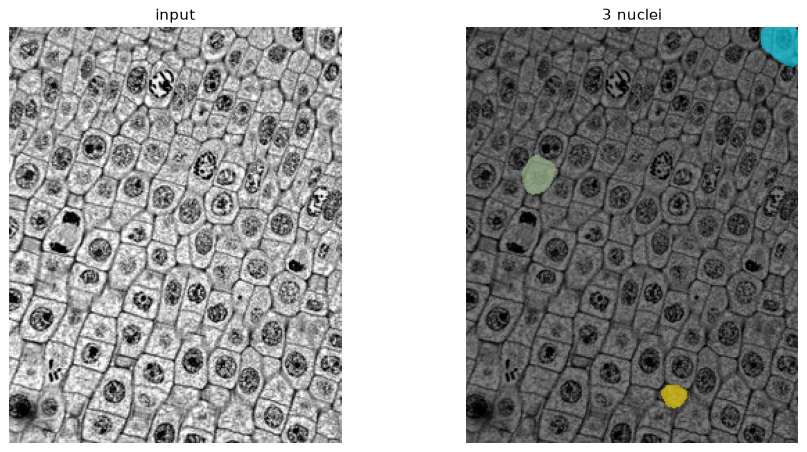

In [16]:
labels = ms.segment(W, gray, prob_thresh=PROB_THRESH, nms_thresh=NMS_THRESH, verbose=False)
print(f"==> {int(labels.max())} nuclei")

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(gray, cmap="gray"); ax[0].set_title("input"); ax[0].axis("off")
ax[1].imshow(label_overlay(gray, labels)); ax[1].set_title(f"{int(labels.max())} nuclei"); ax[1].axis("off")
plt.show()

## That's the whole pipeline

**normalize → U-Net → (prob, 32 distances) → star-convex polygons → NMS →
rasterize.** No flow field, no iterative dynamics, no BatchNorm — the object
shape is read straight off the distance channels, and the only post-processing is
greedy polygon NMS.

Against a controlled StarDist reference, this port matches at **AP@0.5 = 1.000 /
0.997 / 1.000** on the three samples (`python mini_stardist.py <img> --validate`).
Compare `mini_cellpose_walkthrough.ipynb` for the other philosophy: a flow field
you *integrate* to find centers, versus a boundary you *read off* directly.